# J-SVD Explainer - v1.0

In [ ]:
import sys

!{sys.executable} -m pip install xgboost
!{sys.executable} -m pip install catboost
!{sys.executable} -m pip install nbimporter
!{sys.executable} -m pip install tensorflow
!{sys.executable} -m pip install torch

#!git clone https://github.com/AI4LIFE-GROUP/OpenXAI.git
!{sys.executable} -m pip install -e OpenXAI

In [2]:
import time
import numpy as np
import pandas as pd
import nbimporter

import sklearn.ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.sparse.linalg import eigs

import xgboost as xgb
from catboost import CatBoostClassifier

import lime
import lime.lime_tabular

import shap
shap.initjs()

# Load and process dataset

In [3]:
import synthetic_data as syn

synth= syn.synthetic_data_generator(n=500,df=True)

In [4]:
synth= pd.read_csv('datasets/SVD_Exp_synth_data.csv')

# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-1.297434,1.480258,-1.047823,-1.235156
1,-2.255077,1.190942,-0.573914,-3.008057
2,-3.336307,3.258936,-0.030324,-0.361786
3,0.672172,1.928683,-0.456206,-3.051892
4,-1.106266,3.345063,-3.481175,-1.105859


In [5]:
print(np.round(synth.memory_usage().sum() / 10**6, 2), "MB")

0.04 MB


In [6]:
# Normalization
from sklearn.preprocessing import MinMaxScaler

# All dataset is numeric
scaler= MinMaxScaler(feature_range=(0, 1))
norm_x_syn= scaler.fit_transform(np.asarray(x_syn))
norm_x_syn= pd.DataFrame(norm_x_syn, columns=x_syn.columns)

norm_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.425977,0.626863,0.368465,0.345838
1,0.359321,0.603430,0.427822,0.123927
2,0.284062,0.770929,0.495906,0.455156
3,0.563072,0.663184,0.442565,0.118440
4,0.439284,0.777905,0.063690,0.362022


In [7]:
# Standarization
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler().fit(np.asarray(x_syn))
# realiza a padronização (média= 0, variância= 1)
stand_x_syn= scaler.transform(np.asarray(x_syn))
stand_x_syn= pd.DataFrame(stand_x_syn, columns=x_syn.columns)

stand_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-0.103626,0.267269,-0.428075,-0.498028
1,-0.577271,0.116797,-0.225488,-1.265198
2,-1.112041,1.192347,0.006886,-0.120102
3,0.870530,0.500491,-0.175170,-1.284166
4,-0.009076,1.237141,-1.468284,-0.442078


In [8]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(norm_x_syn,y_syn,
                                                                                 train_size=0.80,
                                                                                 random_state=1234)

In [9]:
# Set and train a ML model

xgb_model= xgb.XGBRFClassifier(learning_rate= 0.01,
                               n_estimators= 500,
                               max_depth= 6,
                               gamma= 1,
                               objective= 'binary:logistic',
                               eval_metric='logloss')

eval_set= [(train, labels_train), (test, labels_test)]

xgb_model.fit(train, labels_train, eval_set=eval_set, verbose=False)

acc_all= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))
acc_all

0.96

In [10]:
# the instance to be explained (from train dataset)

target_pos= 9

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

target_inst

,core_1,core_2,noise_1,noise_2
845,0.46423,0.331611,0.465974,0.769212


In [11]:
target_labl

,target
845,0.0


In [12]:
xgb_model.predict_proba(target_inst)

array([[0.5049026 , 0.49509743]], dtype=float32)

# --- J-SVD Explainer Methods ---

In [13]:
# returns the Lp norm of the difference between v1 and v2.
# normalizes the difference between v1 and v2 by v1 (Agarwal, Chirag, et al., 2022)

def lp_norm_dif(v1, v2, p_norm=2, eps=0.001, norm:bool=True):
    
    # arrays can be flattened, so long as ordering is preserved
    flat_dif= np.asarray(v1).flatten() - np.asarray(v2).flatten()
    
    if (norm==True):
        v1_aux= np.asarray(v1).flatten()
        v1_aux= np.clip(v1_aux, eps, None)
        flat_dif= np.divide(flat_dif, v1_aux, where=v1_aux!= 0)

    return np.linalg.norm(flat_dif, ord=p_norm)

In [14]:
# return a DataFrame with replaced values (mean/median/mode/zeros/none to categorical and numeric) 
# to fill train cols. df is post-processed (cat_cols encoded)

def replace_values(df,num_cols,num_type='mean',cat_type='none'):
    cat_values= None
    num_values= None
    
    if (cat_type=='mean'):
        cat_values= df.mean(axis=0).to_frame().T
    elif (cat_type=='median'):
        cat_values= df.median(axis=0).to_frame().T
    elif (cat_type=='mode'):
        cat_values= df.mode(axis=0)
    elif (cat_type=='zeros'):
        cat_values= df.loc[0:0,:].copy()
        cat_values.loc[:,:]= 0
    
    if (num_type=='mode'):
        num_values= df.mode(axis=0)
    elif (num_type=='median'):
        num_values= df.median(axis=0).to_frame().T
    elif (num_type=='mean'):
        num_values= df.mean(axis=0).to_frame().T
    elif (num_type=='zeros'):
        num_values= df.loc[0:0,:].copy()
        num_values.loc[:,:]= 0

    if(cat_type!='none'):
        cat_values[num_cols]= num_values[num_cols]
        return cat_values
    
    return num_values

In [15]:
# transform J-SVD information into SHAP explanation data

def to_sh_exp(explain_vals, base_prob, inst_vals, ft_names):

    sh_exp= shap.Explanation(values=explain_vals, base_values=(base_prob), 
                             data=inst_vals, 
                             feature_names= np.asarray(ft_names).tolist())

    return sh_exp

In [16]:
# x is a n-dimensional data instance in pandas DataFrame format
# h is the magnitude of the neighborhood perturbation

# RETURN a dataset (np.ndarray) with n instances and n features per instance, such that
#        the instance i will be x perturbed by h in the feature i

def perturb_neighborhood(x, h=10e-2):
    
    x_np= np.asarray(x).flatten()

    size= len(x_np)

    pert_ds= []

    for i in range(size):
        pert= np.zeros(size)
        pert[i]= h

        pert_ds.append((x_np + pert))

    pert_ds= np.asarray(pert_ds)

    return pert_ds

In [17]:
perturb_neighborhood(target_inst, 1)

array([[1.46423033, 0.33161074, 0.46597447, 0.76921154],
       [0.46423033, 1.33161074, 0.46597447, 0.76921154],
       [0.46423033, 0.33161074, 1.46597447, 0.76921154],
       [0.46423033, 0.33161074, 0.46597447, 1.76921154]])

In [18]:
# data is the training dataset and labels is the labels dataset
# RETURN n, the number of features in data
#        m, the number of unique classes in labels

def get_n_m_sizes(data, labels):
    
    n= data.shape[1]
    
    m= np.asarray(labels.nunique())[0]
    
    return n, m

In [19]:
get_n_m_sizes(train, labels_train)

(4, 2)

In [20]:
# convert probabilities to log odds

def pred_proba_to_log_odds(p):
    
    return np.log(p/(1-p))

In [21]:
# Expected value can be understood as the average model output across the training set, and the true labels
# SHAP paper mention a dataset "would be predicted if we did not know any features"

# The 'absence of features' or better 'not knowing the feature' needs to be defined/considered carefully. 
# In the context of SHAP it doesn't meant that Xi=0 but it means that we do not know the value of Xi
# but we still may know the distribution of potential values of Xi or we could estimate this distribution 
# based on the data, in practice, a mean value is considered, and then, we average over this predicted 
# probs to each label.

# Receive one instance x_mean from train dataset mean and y_train, the entire labels_train

# RETURN the mean probability of x_mean belonging to the classes in y_train

def expected_value_x_mean(model, x_mean, y_train):
    
    # Expected value over the mean from train data
    p_x= model.predict_proba(x_mean)

    tam= len(y_train)
    pred= 0
    
    for i in range(tam):
        pred= pred+ p_x[0][y_train[i].astype(int)]
        
    avg_pred= pred/ tam
    
    return pred_proba_to_log_odds(avg_pred)

In [48]:
# defining the main function
# model is a m-class classification model, that is, f(x) = (p1(x),...,pm(x))
# x is a n-dimensional data instance (DataFrame or ndarray)

# RETURN p(x), where each p_i(x) accounts for the probability of x belonging to the class i

def ML(model, x):
    
    return pred_proba_to_log_odds(np.squeeze(model.predict_proba(x)))
    
    # n=2, m=2 -- test based on https://www.youtube.com/watch?v=G25sGOWkOuQ
    #a= x[0][0]
    #b= x[0][1]
    #return np.asarray([(a*a-b-1), (a-b*b+1)])
    
    # n=2, m=3 -- test based on https://rh8liuqy.github.io/Finite_Difference.html
    #a= x[0][0]
    #b= x[0][1]
    #return np.asarray([a**2, b**2, a*b])
    
    # test using n=4 and m=2
    #a= x[0][0]
    #b= x[0][1]
    #c= x[0][2]
    #d= x[0][3]
    #return np.asarray([(a*a-b-c*c-d-1), (a-b*b+c+d*d+1)])

In [49]:
ML(xgb_model, target_inst)

array([ 0.01961104, -0.01961095], dtype=float32)

In [23]:
# First-order or forward difference approximation of f'(x) -- the error is proportional to h^1

# we approximate the Jacobian using Finite Difference Method for systems of nonlinear equations
# when using finite differences, we don't need to know the M definition. We just need to call it 
# a couple of times with different parameters

# the function that maps xp to f(x) + Jf(x)⋅(xp - x) is the best linear approximation of f(xp) 
# for all points xp close to x

# f(xp) ~ f(x) + Jf(x).(xp - x)^T   --> f is differentiable in x with xp a point close to x
# f(x + h) ~ f(x) + Jf(x).h         --> x + h = xp  -->  h = xp - x

# model is a m-class classification model, that is, f(x) = (p1(x),...,pm(x))
# data is a n-dimensional data instance in pandas DataFrame format
# labels is a 1-dimensional value in pandas DataFrame format represeting the data true classe
# dimensions represent the number of features in train data (n) and the number of classes (m)
# h is a small number representing the magnitude of neighborhood perturbation. If it is too big, 
#   we will get big truncation errors. If it is too small, we will get big roundoff errors
# eps is a small number of tolerance to calibrate by trial and error until we get good results
# max_itr is the max iteration of generalized finite difference method

# RETURN a m x n matrix Jf(x) approximating the jacobian of model

def get_jacobian_matrix(model, data, label, dimensions, h=10e-2, eps=10e-3, max_itr=1):
    
    if not (h> 0):
        raise ValueError("h parameter must be greater than zero!")
    else: 
        ncol, mrow= dimensions
    
        j_matrix= np.zeros((mrow, ncol))

        xn= np.asarray(data)
        
        in_loop= True
        itr= 0

        while (in_loop== True):   # Jacobian is the partial derivatives of every variable in M (model) 
            itr= itr + 1          # against every function in M
                                  # Jacobian describes how a local change to the input changes the output
            fxn= ML(model, xn)

            # [f(xp) - f(xn)]/h ~ Jf(xn)
            xp= perturb_neighborhood(xn, h)

            for i in range(ncol):
                fxp= ML(model, np.asarray([xp[i]]))

                j_fxn= (fxp - fxn)/ h

                j_matrix[:, i]= j_fxn

            
            xn_1= xn - (np.linalg.pinv(j_matrix)).dot(fxn.T)

            if not (itr< max_itr):   # stop conditions
                in_loop= False
            elif (lp_norm_dif(xn_1, xn, norm=False)< eps):
                in_loop= False
            elif (lp_norm_dif(fxn, np.zeros(fxn.shape), norm=False)< eps):
                in_loop= False

            xn= xn_1.copy()

        return j_matrix

In [24]:
# Second-order or centered difference approximation of f'(x) -- the error is proportional to h^2
# based on the combining of different Taylor series expansions

# the function that maps xp to f(x) + Jf(x)⋅(xp - x) is the best linear approximation of f(xp) 
# for all points xp close to x

# f(xp) ~ f(x) + Jf(x).(xp - x)^T   --> f is differentiable in x with xp a point close to x
# f(x + h) ~ f(x) + Jf(x).h         --> x + h = xp  -->  h = xp - x

# inputs and outputs are similar to get_jacobian_matrix

def get_jacobian_matrix_v2(model, data, label, dimensions, h=10e-2, eps=10e-3, max_itr=1):
       
    if not (h> 0):
        raise ValueError("h parameter must be greater than zero!")
    else:
        ncol, mrow= dimensions

        j_matrix= np.zeros((mrow, ncol))

        xn= np.asarray(data)
        
        in_loop= True
        itr= 0
        
        while (in_loop== True):   # Jacobian is the partial derivatives of every variable in M (model) 
            itr= itr + 1          # against every function in M
                                  # Jacobian describes how a local change to the input changes the output           
            fxn= ML(model, xn)
            
            xpp= perturb_neighborhood(xn, +h)
            xpn= perturb_neighborhood(xn, -h)
            #print(xpp)
            #print(xpn)
            
            for i in range(ncol):
                fxpp= ML(model, np.asarray([xpp[i]]))
                fxpn= ML(model, np.asarray([xpn[i]]))
                #print(fxpp)
                #print(fxpn)

                dij= (fxpp - fxpn) / (2*h)

                j_matrix[:, i]= dij
                
            
            xn_1= xn - (np.linalg.pinv(j_matrix)).dot(fxn.T)

            if not (itr< max_itr):   # stop conditions
                in_loop= False
            elif (lp_norm_dif(xn_1, xn, norm=False)< eps):
                in_loop= False
            elif (lp_norm_dif(fxn, np.zeros(fxn.shape), norm=False)< eps):
                in_loop= False

            xn= xn_1.copy()
            
        return j_matrix

In [1876]:
# test based on https://rh8liuqy.github.io/Finite_Difference.html

dim= (2,3)

get_jacobian_matrix(xgb_model, [[1,2]], target_labl, dim, 
                    h=10e-2, eps=10e-6, max_itr=1)

array([[2.1, 0. ],
       [0. , 4.1],
       [2. , 1. ]])

In [1885]:
get_jacobian_matrix_v2(xgb_model, [[1,2]], target_labl, dim,
                       h=10e-3, eps=10e-6, max_itr=1)

array([[2., 0.],
       [0., 4.],
       [2., 1.]])

In [1426]:
# test based on https://www.youtube.com/watch?v=G25sGOWkOuQ

dim= (2,2)

E= np.asarray([[1,2]])

print(get_jacobian_matrix(xgb_model, E, target_labl, dim, 
                          h=10e-2, eps=10e-6, max_itr=1000))

[[ 3.33607069 -1.        ]
 [ 1.         -3.33607044]]


In [1424]:
print(get_jacobian_matrix_v2(xgb_model, E, target_labl, dim, 
                             h=10e-2, eps=10e-6, max_itr=1000))

[[ 3.23606799 -1.        ]
 [ 1.         -3.23606798]]


In [1333]:
print(get_jacobian_matrix(xgb_model, target_inst, target_labl, get_n_m_sizes(train, labels_train), 
                          h=10e-2, eps=10e-6, max_itr=1))

[[ 0.00030274  0.          0.         -0.00016483]
 [-0.00030393  0.          0.          0.0001635 ]]


In [1892]:
print(get_jacobian_matrix_v2(xgb_model, target_inst, target_labl, get_n_m_sizes(train, labels_train), 
                             h=0.1, eps=10e-6, max_itr=1))

[[0.56423033 0.33161074 0.46597447 0.76921154]
 [0.46423033 0.43161074 0.46597447 0.76921154]
 [0.46423033 0.33161074 0.56597447 0.76921154]
 [0.46423033 0.33161074 0.46597447 0.86921154]]
[[0.36423033 0.33161074 0.46597447 0.76921154]
 [0.46423033 0.23161074 0.46597447 0.76921154]
 [0.46423033 0.33161074 0.36597447 0.76921154]
 [0.46423033 0.33161074 0.46597447 0.66921154]]
[ 0.01964131 -0.01964135]
[ 0.01971098 -0.01971095]
[ 0.01961104 -0.01961095]
[ 0.01961104 -0.01961095]
[ 0.01961104 -0.01961095]
[ 0.01958053 -0.0195805 ]
[ 0.01959456 -0.0195946 ]
[ 0.01961104 -0.01961095]
[[-3.48323956e-04  0.00000000e+00  1.52550638e-04 -8.24127346e-05]
 [ 3.48016620e-04  0.00000000e+00 -1.52261928e-04  8.17514956e-05]]


In [25]:
# If h is too big, we will get big truncation errors. If h is too small, we will get big roundoff errors

# the function that maps xp to f(x) + Jf(x)⋅(xp - x) is the best linear approximation of f(xp) 
# for all points xp close to x

# f(xp) ~ f(x) + Jf(x).h   -->   f is differentiable in x with xp a point close to x
# then f(x) ~ f(xp) - Jf(x).h

# here we find an optimized value to h based on a binary search strategy
# similar parameters from get_jacobian_matrix
# h_max and h_min are small numbers representing the max and min range of neighborhood perturbation
# finite_diff_version=1 to use forward difference approximation
#                    =2 to use centered difference approximation

# RETURN an optimum h value (accordind to eps) and its related jacobian_matrix

def optimize_h(model, data, label, dimensions, h_min=10e-9, h_max=1, eps=10e-6, 
               max_itr=100, finite_diff_version=2):
    
    h_left= h_min
    h_rght= h_max
    
    xn= np.asarray(data)
    fx= ML(model, xn)
    xn_zeros= np.zeros(xn.shape[1])
    fx_zeros= np.zeros(fx.shape[0])
    
    in_loop= True
    itr= 0
    h= 0
    j_matrix= []

    while (in_loop== True):
        itr= itr + 1
        h_midd= (h_rght+h_left)/2   # we get the middle distance between h_min and h_max
        
        if (finite_diff_version==1):
            jm_rght= get_jacobian_matrix(model, data, label, dimensions, h=h_rght, eps=eps, max_itr=1)
        else:  # if not (finite_diff_version==1) then use get_jacobian_matrix_v2
            jm_rght= get_jacobian_matrix_v2(model, data, label, dimensions, h=h_rght, eps=eps, max_itr=1)
        
        xp= xn + h_rght
        fxp= ML(model, xp)
        
        # the linear map Jf(x).h is known as the derivative or the differential of f at x
        jfxh= jm_rght.dot((xn_zeros+h_rght).T).T
        # f(x) ~ f(xp) - Jf(x).h
        fxj_rght= fxp - jfxh
        
        if (lp_norm_dif(jfxh, fx_zeros, norm=False)== 0.0):   # if h_max is too small, jacobian_matrix is a 
            raise ValueError("h_max parameter is too small!") # matrix of zeros
            
        elif (lp_norm_dif(fxj_rght, fx, norm=False)< eps):  # we first check the h_max, if it accomplishes
            in_loop= False                                  # the minimum error, we finish the loop returning
            h= h_rght                                       # h_max and its jacobian
            j_matrix= np.asarray(jm_rght)
            
        else:                                               # if h_max does not accomplishes, then we reduce
            if (finite_diff_version==1):                    # the h interval in a binary search mode 
                jm_midd= get_jacobian_matrix(model, data, label, dimensions, h=h_midd, eps=eps, max_itr=1)
            else:  # if not (finite_diff_version==1) then use get_jacobian_matrix_v2
                jm_midd= get_jacobian_matrix_v2(model, data, label, dimensions, h=h_midd, eps=eps, max_itr=1)
            
            xp= xn + h_midd
            fxp= ML(model, xp)
            
            # the linear map Jf(x).h is known as the derivative or the differential of f at x
            jfxh= jm_midd.dot((xn_zeros+h_midd).T).T
            # f(x) ~ f(xp) - Jf(x).h
            fxj_midd= fxp - jfxh
            
            if (lp_norm_dif(jfxh, fx_zeros, norm=False)== 0.0):  # stop conditions
                h_left= h_midd   # if h_midd is too small, then we will increase it by turning h_min = h_midd
                
                if not (itr< max_itr):
                    in_loop= False
                    h= h_rght
                    j_matrix= np.asarray(jm_rght)
                    
            elif (lp_norm_dif(fxj_midd, fx, norm=False)< eps):
                h_left= h_midd  # h_midd is small but it may be not the optimum value, then we will increase
                                # it by turning h_min = h_midd
                if ((lp_norm_dif(h_rght, h_left, norm=False)< eps) or (not (itr< max_itr))):
                    in_loop= False
                    h= h_midd                      # in this case, h_midd is an optimized value
                    j_matrix= np.asarray(jm_midd)
            else:
                h_rght= h_midd   # if none of the previous criteria, we then reduce h_max
                
                if not (itr< max_itr):
                    in_loop= False
                    h= h_midd
                    j_matrix= np.asarray(jm_midd)
    
    return h, j_matrix

In [2001]:
# test based on https://rh8liuqy.github.io/Finite_Difference.html

dim= (2,3)

optimize_h(xgb_model, [[1,2]], target_labl, dim, h_min=10e-9, h_max=1, eps=10e-6, max_itr=100, 
           finite_diff_version=2)

(0.002399454556083679,
 array([[2., 0.],
        [0., 4.],
        [2., 1.]]))

In [26]:
from scipy.linalg import svd

# j_matrix is the jacobian m x n matrix (ndarray)

# RETURN U, an m x m matrix. The columns of the U matrix hold the left-singular vectors of j_matrix
#        Sigma, an m x n diagonal matrix with the singular values of the original j_matrix
#        VT, the transpose of an n x n matrix. The columns of V hold the right-singular vectors of j_matrix

# U and V are orthogonal matrices and Sigma is a diagonal matrix whose diagonal elements are non-negative 
# values called singular values

def svd_decomposition(j_matrix):
    
    m, n= j_matrix.shape

    U, Sigma_v, VT= svd(j_matrix)   # singular-value decomposition
                                    # the elements returned from the svd() cannot be multiplied directly
    Sigma= np.zeros((m, n))         # Sigma_v is a vector that must be converted into a diagonal matrix
    
    Sigma[:n, :m]= np.diag(Sigma_v)
    
    #print(U.dot(Sigma.dot(VT)))    # test - this eq. must be equal to j_matrix
    
    return U, Sigma, VT

In [893]:
A= np.array([[1, 2, 3, 4], 
             [5, 6, 7, 8]])

svd_decomposition(A)

(array([[-0.37616823,  0.92655138],
        [-0.92655138, -0.37616823]]),
 array([[14.22740741,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  1.25732984,  0.        ,  0.        ]]),
 array([[-0.35206169, -0.44362578, -0.53518987, -0.62675396],
        [-0.75898127, -0.3212416 ,  0.11649807,  0.55423774],
        [-0.40008743,  0.25463292,  0.69099646, -0.54554195],
        [-0.37407225,  0.79697056, -0.47172438,  0.04882607]]))

In [27]:
# x is a n-dimensional data instance (ndarray)
# U, S, VT are the outputs from svd_decomposition() (ndarray)

# f(xp) ~ f(x) + Jf(x).(xp - x)^T   --> x + h = xp  -->  h = xp - x
# f(x + h) ~ f(x) + Jf(x).h^T       f is differentiable in x with xp a point close to x

# RETURN Eq. (2)  ->  Jf(x) · x

# the linear map Jf(x).h is known as the derivative or the differential of f at x

def interpret_svd_coords(x, U, S, VT):
    
    m, n= S.shape
    j= np.min([m,n])
    
    UT= U.T   # we need the columns of U and V, then we use the transpose U. V is transposed in VT

    s= np.diag(S[0:j])  # s are the singular values in Sigma
    
    j_mx_x= []
    
    for i in range(j):
                     # u_i and v_i denoting the columns of U and V respectively
        u_i= UT[i]   # m-dimensional vector
        v_i= VT[i]   # n-dimensional vector
        s_i= s[i]
        
        #print(u_i)
        #print(v_i)
        #print(s_i)
        
        j_mx_x.append((s_i * (v_i).dot(x.T)) * u_i)  # Eq. (2)
        
    j_mx_x= np.sum(np.asarray(j_mx_x), axis=0)
    
    #print(x)
    #print(VT.dot(x.T))
    #print(U.dot(S.dot(VT.dot(x.T))))    # test - this eq. must be equal to j_mx_x
        
    return j_mx_x/2  # because Jf(x).x ~ 2*f(x)

In [1604]:
U, S, VT= svd_decomposition(A)

interpret_svd_coords(np.asarray(target_inst).flatten(), U, S, VT)

array([2.80111068, 6.86316484])

In [28]:
# here we compute Eq. 3 to measure importance phi_i of each attribute i
# x is a n-dimensional data instance (ndarray)
# U, S, VT are the outputs from svd_decomposition() (ndarray)

# RETURN the measured importance phi_i of each attribute i from x

def add_importance_attribution(x, U, S, VT):
    
    m, n= S.shape
    j= np.min([m,n])
    
    phi= np.zeros(n)
    
    s= np.diag(S[0:j])  # s are the singular values in Sigma, s1 ≥ s2 ≥ ··· ≥ sj
    
    s1= s[np.argmax(s)]
                        # vectors v_i=(v_1i,..., v_ni) give rise to an orthonormal basis for a j-dimensional 
    for i in range(n):  # subspace in R^n, with value v_ji interpreted as the importance of attrib j for v_i
        importance= 0   # for this reason we transpose VT to get V, because each line i in V has the 
        vi= (VT.T)[i]   # importances of the attribute i we need to calculate phi_i

        for k in range(j):
            sk= s[k]    # the scalars (vtk.x) from VT account for the alignment of x with each basis vector 
            vtk= VT[k]  # and thus for the importance of the attributes in the mapping Jf(x)·x
            vik= vi[k]  # vik accounts for v_i=(v_ji,..., v_jn), a column from VT and a line of V
            
            phi[i]= phi[i] + (sk/s1)*(vtk.dot(x.T))*(vik)  # Eq. 3
            # the fraction sk/s1 ensures that the attribute values given by the coordinates of v_1 are the 
            # most important, the values from v_2 are the second most important, and so on
    
    return phi/2  # because Jf(x).x ~ 2*f(x)

In [1606]:
U, S, VT= svd_decomposition(A)

add_importance_attribution(np.asarray(target_inst).flatten(), U, S, VT)

array([0.18270202, 0.23082928, 0.27895654, 0.32708381])

In [29]:
# here we put the importance vector into appropriate scale according to E[f(X)] and f(x) 

# RETURN the importances vector scaled

def rectified_feature_importances(e_fx, fx, importances):
      
    distance= np.abs(e_fx - fx)
    rect_importances= []
    
    if (e_fx < fx):    # here we have a prediction value greater than the expected value, then
                       # we need sum(importances)> 0 because features sum must increase to E[f(X)]
        if (np.sum(importances)> 0):
            rect_importances= (1)* importances  # rectification step to fix a signal mismatch
        else:
            rect_importances= (-1)*importances
        
    elif (e_fx >= fx): # here we have a prediction value smaller than the expected value, then
                       # we need sum(importances)< 0 because features sum must decrease to E[f(X)]
        if (np.sum(importances)< 0):
            rect_importances= (1)* importances  # rectification step to fix a signal mismatch
        else:
            rect_importances= (-1)*importances
    
    # transform values from rect_importances into distance values accordind to e_fx and fx        
    distance_imps= np.abs(np.sum(rect_importances))
    #distance_imps= np.clip(distance_imps, 0.01, None)
    
    d_ratio= distance / distance_imps
    d_ratio= np.log(1 + d_ratio)
    
    #d_ratio= np.clip(d_ratio, None, 1)
    #d_ratio= 1
    #rect_importances= (1)*importances

    dist_importances= d_ratio * rect_importances
            
    return dist_importances

In [30]:
# model is a treined m-class classification model, that is, f(x) = (p1(x),...,pm(x))
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data true labels
# x_to_exp_data and x_to_exp_label are the instance to be explained and its label, both pd.DataFrame
# h is a small number representing the magnitude of neighborhood perturbation
#   h_min and h_max represent an h interval of calibration
# eps is a small number of tolerance to calibrate by trial and error until we get good results
# max_itr is the max iteration to calibrate h
# finite_diff_version=1 to use forward difference approximation
#                    =2 to use centered difference approximation

# RETURN local feature importances of the instance x_to_exp_data relative to model classifier

def jsvd_explainer(model, data, labels, x_to_exp_data, x_to_exp_label, h_min=10e-6, h_max=1, 
                   eps=10e-5, max_itr=100, finite_diff_version=2, verbose:bool=False):
    
    start= time.time()
    
    n, m= get_n_m_sizes(data, labels)
    
    dimensions= (n,m)
    
    mean_inst= replace_values(data, data.columns, num_type='mean', cat_type='none')
    # e_fx can be understood as the average model output across the training set X when Xi is not known
    # for this reason, the data mean is used
    e_fx= expected_value_x_mean(model, mean_inst, labels.values.ravel())
    
    # fx_pred is the model predicted class output from the instance under explanation
    fx_pred= model.predict(x_to_exp_data)[0]
    # fx is the model probability output from the instance under explanation
    fx= ML(model, x_to_exp_data)[fx_pred]
    #"""
    h_opt, j_matrix= optimize_h(model, x_to_exp_data, x_to_exp_label, dimensions, h_min=h_min, h_max=h_max, 
                                eps=eps, max_itr=max_itr, finite_diff_version=finite_diff_version)
    """
    if (finite_diff_version==1):
        j_matrix= get_jacobian_matrix(model, x_to_exp_data, x_to_exp_label, dimensions,
                                      h=h_min, eps=eps, max_itr=1)
        h_opt= h_min
    else:  # if not (finite_diff_version==1) then use get_jacobian_matrix_v2
        j_matrix= get_jacobian_matrix_v2(model, x_to_exp_data, x_to_exp_label, dimensions,
                                         h=h_min, eps=eps, max_itr=1)
        h_opt= h_min
    #"""
    U, S, VT= svd_decomposition(j_matrix)
    
    x= np.asarray(x_to_exp_data).flatten()
    
    jsvd_phis= add_importance_attribution(x, U, S, VT)
    
    jsvd_phis= rectified_feature_importances(e_fx, fx, jsvd_phis)
    
    jsvd_ranking= pd.Series(jsvd_phis, index=x_to_exp_data.columns).sort_values(ascending=False)
    
    jsvd_sh_exp= to_sh_exp(jsvd_phis, e_fx, np.asarray(x_to_exp_data)[0], x_to_exp_data.columns)
    
    if (verbose==True):
        print("Target instance: ")
        print(x)
        print("\nPredicted probabilities p_i(x) (log-odds): ")
        print(fx)
        print("\nExpected predicted value E[f(X)] (log-odds): ")
        print(np.around(e_fx, decimals=6))
        print("\nJacobian Matrix Jf(x): ")
        print(j_matrix)
        print("\nh optimized: ")
        print(h_opt)
        print("\nJacobian interpretation Jf(x) · x: ")
        j_mx= interpret_svd_coords(x, U, S, VT)
        print(j_mx)
        print("\nJacobian-SVD Feature Importances: ")
        print(np.around(jsvd_phis, decimals=6))
        end= time.time()
        print("\n--- %s seconds ---" % np.round((end- start), 2))
    
    return jsvd_phis, jsvd_ranking, jsvd_sh_exp

# Tests using simplified model

In [31]:
# test using n=4 and m=2
# based on https://rh8liuqy.github.io/Finite_Difference.html

x_test= np.asarray([[1,2]])

x_test

array([[1, 2]])

In [32]:
# f(xp) ~ f(x) + Jf(x).h

h_test= 10e-2
h_test

0.1

In [35]:
# Jf(x)

dim= (2,3)

h_top, jac_test= optimize_h(xgb_model, x_test, target_labl, dim, h_min=10e-2, h_max=0.1, eps=10e-2, 
                            max_itr=100, finite_diff_version=2)

print(jac_test)

[[2. 0.]
 [0. 4.]
 [2. 1.]]


In [36]:
h_top

0.1

In [37]:
xp_test= x_test + h_top

xp_test

array([[1.1, 2.1]])

In [38]:
# f(x)

fx_test= ML(xgb_model, x_test)

fx_test

array([1, 4, 2])

In [39]:
# f(xp)

fxp_test= ML(xgb_model, xp_test)

fxp_test

array([1.21, 4.41, 2.31])

In [40]:
# f(x) ~ f(xp) - Jf(x).h

fx_j= fxp_test - jac_test.dot((np.zeros(x_test.shape[1])+h_top).T).T

fx_j

array([1.01, 4.01, 2.01])

In [41]:
# Jf(x).h

jac_test.dot((np.zeros(x_test.shape[1])+h_top).T).T

array([0.2, 0.4, 0.3])

In [42]:
# Jf(x).h ~ f(xp) - f(x)

(fxp_test-fx_test)

array([0.21, 0.41, 0.31])

In [43]:
# Jf(x).x   ==>   2*f(x)

jac_test.dot(x_test.T).T

array([[2., 8., 4.]])

In [44]:
# Jf(x).x

U_test, S_test, VT_test= svd_decomposition(jac_test)

# Eq. 2
jfx_test= interpret_svd_coords(x_test.flatten(), U_test, S_test, VT_test)

jfx_test

array([1., 4., 2.])

In [45]:
S_test

array([[4.17425789, 0.        ],
       [0.        , 2.75237554],
       [0.        , 0.        ]])

In [46]:
# Eq. 3   ==>   need to adjust according to the pred class

add_importance_attribution(x_test, U_test, S_test, VT_test)

array([0.40619574, 1.01990662])

In [47]:
# Eq. 3   ==>   adjusted according to the pred class
# now f(x) = phi_0 + sum(phi(x))

rectified_feature_importances(0, jfx_test[0], add_importance_attribution(x_test, U_test, S_test, VT_test))

array([0.21582841, 0.5419181 ])

# Tests using xgb_model on synthetic data

Target instance: 
[0.47330104 0.65383311 0.87131331 0.94010178]

Predicted probabilities p_i(x) (log-odds): 
0.019757964

Expected predicted value E[f(X)] (log-odds): 
-0.000196

Jacobian Matrix Jf(x): 
[[ 0.02304566 -0.03295141 -0.00061467  0.0008913 ]
 [-0.02304579  0.03295158  0.00061524 -0.00089095]]

h optimized: 
0.050439453125000006

Jacobian interpretation Jf(x) · x: 
[-0.00516742  0.00516786]

Jacobian-SVD Feature Importances: 
[-0.036798  0.052615  0.000984 -0.001422]

--- 0.45 seconds ---


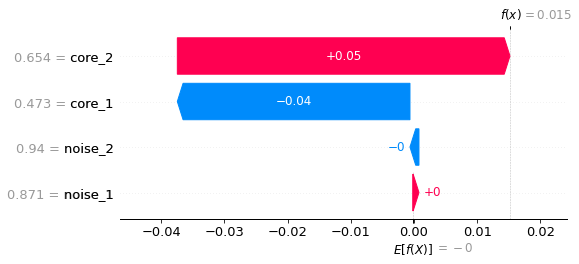

In [50]:
# J-SVD explainer to only one instance (local explanation)

target_pos= 2

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model, train, labels_train, target_inst, target_labl,
                                                   h_min=0.05, h_max=0.5, eps=10e-5, max_itr=10, 
                                                   finite_diff_version=2, verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

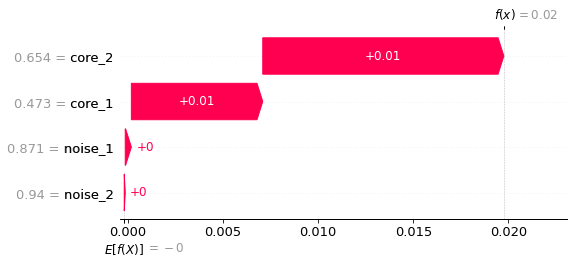

In [109]:
# SHAP explainer to only one instance (local explanation)

shap.plots.waterfall(shap_values[target_pos])

In [266]:
import matplotlib.pyplot as plt

# PLOT a beeswarm plot (SHAP-like) using jsvd_explainer explanations

# model is a treined m-class classification model, that is, f(x) = (p1(x),...,pm(x))
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data true labels
# h is a small number representing the magnitude of neighborhood perturbation
#   h_min and h_max represent an h interval of calibration
# eps is a small number of tolerance to calibrate by trial and error until we get good results
# max_itr is the max iteration to calibrate h
# finite_diff_version=1 to use forward difference approximation
#                    =2 to use centered difference approximation

# RETURN nothing

def jsvd_plots_sh_beeswarm(model, train, labels_train, h_min=10e-6, h_max=1, eps=10e-5, max_itr=100, 
                           finite_diff_version=2, verbose:bool=False):
    
    start= time.time()

    train_size= train.shape[0]
    importance_values= []

    for i in range(train_size):
        #print(i)
        target_inst= train.iloc[i].to_frame().T
        target_labl= labels_train.iloc[i].to_frame().T

        j_phis, j_ft_rk, j_sh_exp= jsvd_explainer(model, train, labels_train, target_inst, target_labl,
                                                  h_min=h_min, h_max=h_max, eps=eps, max_itr=max_itr, 
                                                  finite_diff_version=finite_diff_version, verbose=False)

        #shap.plots.waterfall(j_sh_exp)
        importance_values.append(j_phis)

    base_vector= []
    base_vector= [j_sh_exp.base_values for i in range(train_size)]

    j_exp= to_sh_exp(np.asarray(importance_values), np.asarray(base_vector), np.asarray(train), 
                        train.columns)

    end= time.time()
    if (verbose==True):
        print("\n--- %s seconds ---" % np.round((end- start), 2))

    shap.plots.beeswarm(j_exp, show=False)
    
    # get the current figure and axes objects
    fig, ax= plt.gcf(), plt.gca()

    # it is need to fix a bug between shap.plots and matplotlib on color_bar creation
    fig.axes[-1].set_aspect('auto')  # the handling of colorbar or box aspect ratio has 
    plt.tight_layout()               # been changed in matplotlib.pyplot version 3.5
    fig.axes[-1].set_box_aspect(50)

    # modifying main plot parameters
    ax.set_xlabel("J-SVD value (impact on model output)", fontsize=13)  # change from SHAP to J-SVD
    
    plt.show()


--- 41.28 seconds ---


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


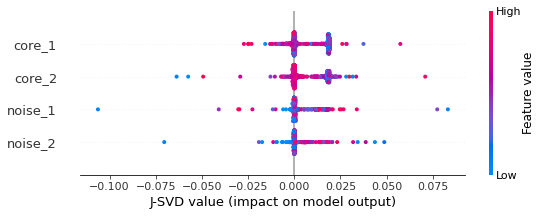

In [264]:
# J-SVD beeswarm plot -- finite_diff_version=1

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=0.05, h_max=0.5, eps=10e-3, max_itr=10, 
                       finite_diff_version=1, verbose=True)


--- 119.2 seconds ---


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


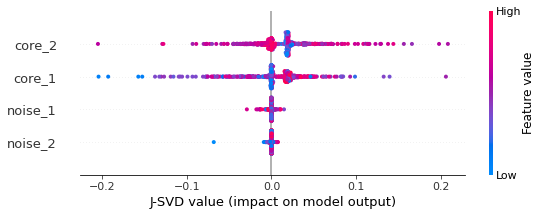

In [265]:
# J-SVD beeswarm plot -- finite_diff_version=2

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=0.05, h_max=0.5, eps=10e-3, max_itr=10, 
                       finite_diff_version=2, verbose=True)

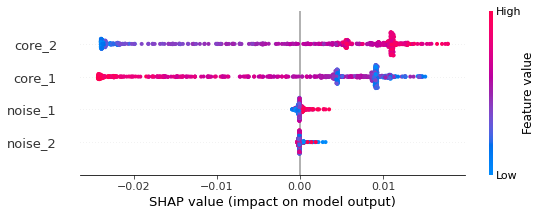

In [261]:
# Tests using SHAP

explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

# TODO list

In [51]:
# DONE -- update the benchmarking methods to run jsvd_explainer
# DONE -- define the descriptor parameters required by benchmarking methods to run our synthetic data
# test our synthetic data
# DONE -- create an inputs-labels synthetic dataset using OpenXAI
# DONE -- split inputs and labels from OpenXAI into train and test datasets
# DONE -- define the descriptor parameters required by benchmarking methods to run synthetic data from OpenXAI
# DONE -- train an ML model on data from OpenXAI
# test using OpenXAI synthetic data

# --- Benchmarking ---

In [52]:
import openxai

# Utils
import torch
import pickle

# Data loaders
from openxai.dataloader import return_loaders

# Perturbation methods required for the computation of the relative stability metrics
from openxai.explainers.catalog.perturbation_methods import NormalPerturbation
from openxai.explainers.catalog.perturbation_methods import NewDiscrete_NormalPerturbation

# Method -- Relative Input/Output Stability

In [53]:
# Relative Input/Output Stability
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels (Pandas DataFrame)
# perturbation is a OpenXAI perturbation object
# descriptor define the parameters to explanations and data perturbations

# approximates the maximum L-p distance between explanations in a neighborhood around input x
# RETURN RIS (ris=True) or ROS (ris=False) metric for J-SVD, SHAP, and LIME.
# max_mean=True RETURN RIS/ROS max stability ratios value, 
# max_mean=False RETURN RIS/ROS mean stability ratios value

def relative_stability(model, data, labels, perturbation, descriptor, ris:bool=True, max_mean:bool=True):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    #tensor_train = tensor_train[0:10, :]
    #tensor_labels= tensor_labels[0:10]
    # ---------------------------------------
    
    jsvd_stability_ratios= []
    shap_stability_ratios= []
    lime_stability_ratios= []
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]

        # data point prediction
        y_pred= torch.from_numpy(model.predict(np.asarray(x_data.unsqueeze(0))))

        # x_data and its label as pd.DataFrame
        target_i= pd.DataFrame(x_data, data.columns).T
        target_l= pd.DataFrame(data=[np.int64(tensor_labels[i_data])], columns=labels.columns)
        
        jsvd_x_stability_ratios= []
        shap_x_stability_ratios= []
        lime_x_stability_ratios= []

        # ------------------------------------ x_data explanation
        # data point explanation -- J-SVD
        jsvd_x_exp, jsvd_x_ft, jsvd_x_sh= jsvd_explainer(model, data, labels, target_i, target_l,
                                                        h_min=descriptor['h_min'], h_max=descriptor['h_max'],
                                                        eps=descriptor['jacobian_eps'],
                                                        max_itr=descriptor['max_itr'],
                                                        finite_diff_version=descriptor['finite_diff_version'],
                                                        verbose=False)

        jsvd_x_exp= torch.from_numpy(jsvd_x_exp)


        # data point explanation -- SHAP
        shap_exp_gen= shap.Explainer(model, data)
        shap_x_exp= shap_exp_gen(target_i)

        shap_x_exp= (torch.from_numpy(shap_x_exp.values)).squeeze()


        # data point explanation -- LIME
        lime_exp_gen= lime.lime_tabular.LimeTabularExplainer(np.asarray(train), 
                                                             feature_names=np.asarray(train.columns), 
                                                             class_names=np.asarray([0,1]), verbose=False, 
                                                             mode='classification', 
                                                             discretize_continuous=False)

        lime_scores= lime_exp_gen.explain_instance(np.asarray(target_i)[0], model.predict_proba, 
                                                     num_features=train.shape[1])

        lime_x_exp= torch.from_numpy(lime_exp_in_data_order(lime_scores, train.shape[1]))

        # ------------------------------------ x_data perturbation
        # data point perturbation
        x_pert_samples= perturbation.get_perturbed_inputs(original_sample=x_data,
                                                          feature_mask=descriptor['mask'],
                                                          num_samples=descriptor['num_samples'],
                                                          max_distance=descriptor['pert_max_distance'],
                                                          feature_metadata=descriptor['feature_metadata'])

        # take the first num_perts points that have the same predicted class label
        y_pert_preds= torch.from_numpy(model.predict(x_pert_samples.numpy()))

        ind_same_class= (y_pert_preds == y_pred).nonzero()[: descriptor['num_perts']].squeeze()
        x_pert_samples= torch.index_select(input=x_pert_samples, dim=0, index=ind_same_class)

        y_pert_preds= torch.from_numpy(model.predict(x_pert_samples.numpy()))

        # ------------------------------------ explain each x_data perturbation
        jsvd_exp_pert_samples= torch.zeros_like(x_pert_samples)
        shap_exp_pert_samples= torch.zeros_like(x_pert_samples)
        lime_exp_pert_samples= torch.zeros_like(x_pert_samples)

        # For each perturbation, calculate the explanation
        for i, x_pert in enumerate(x_pert_samples):

            target_i= pd.DataFrame(x_pert, data.columns).T
            target_l= pd.DataFrame(data=[np.int64(y_pert_preds[i])], columns=labels.columns)

            # perturbed data point explanation -- J-SVD
            jsvd_exp, jsvd_ft, jsvd_sh= jsvd_explainer(model, data, labels, target_i, target_l, 
                                                       h_min=descriptor['h_min'], h_max=descriptor['h_max'],
                                                       eps=descriptor['jacobian_eps'],
                                                       max_itr=descriptor['max_itr'],
                                                       finite_diff_version=descriptor['finite_diff_version'],
                                                       verbose=False)

            jsvd_exp_pert_samples[i, :]= torch.from_numpy(jsvd_exp)

            # perturbed data point explanation -- SHAP
            shap_exp= shap_exp_gen(target_i)
            shap_exp_pert_samples[i, :]= torch.from_numpy(shap_exp.values)

            # perturbed data point explanation -- LIME
            lime_scores= lime_exp_gen.explain_instance(np.asarray(target_i)[0], model.predict_proba, 
                                                       num_features=train.shape[1])

            lime_exp_pert_samples[i, :]= torch.from_numpy(lime_exp_in_data_order(lime_scores, train.shape[1]))

        # ------------------------------------ compute stability for each explanator and x_data perturbation
        for sample_i, x_pert in enumerate(x_pert_samples):

            if (ris==True):
                jsvd_stability_measure= ris_measure(x_data, x_pert, 
                                                   jsvd_x_exp, jsvd_exp_pert_samples[sample_i], 
                                                   p_norm=descriptor['p_norm'], eps=descriptor['eps'])

                shap_stability_measure= ris_measure(x_data, x_pert, 
                                                    shap_x_exp, shap_exp_pert_samples[sample_i], 
                                                    p_norm=descriptor['p_norm'], eps=descriptor['eps'])

                lime_stability_measure= ris_measure(x_data, x_pert, 
                                                    lime_x_exp, lime_exp_pert_samples[sample_i], 
                                                    p_norm=descriptor['p_norm'], eps=descriptor['eps'])
            else:
                x_pert= x_pert.unsqueeze(0)

                jsvd_stability_measure= ros_measure(model, x_data.unsqueeze(0), x_pert, 
                                                   jsvd_x_exp, jsvd_exp_pert_samples[sample_i], 
                                                   p_norm=descriptor['p_norm'], eps=descriptor['eps'])

                shap_stability_measure= ros_measure(model, x_data.unsqueeze(0), x_pert, 
                                                    shap_x_exp, shap_exp_pert_samples[sample_i], 
                                                    p_norm=descriptor['p_norm'], eps=descriptor['eps'])

                lime_stability_measure= ros_measure(model, x_data.unsqueeze(0), x_pert, 
                                                    lime_x_exp, lime_exp_pert_samples[sample_i], 
                                                    p_norm=descriptor['p_norm'], eps=descriptor['eps'])
            
            # stability measures for each x_data perturbation -- a processing
            jsvd_x_stability_ratios.append(jsvd_stability_measure)
            shap_x_stability_ratios.append(shap_stability_measure)
            lime_x_stability_ratios.append(lime_stability_measure)
        
        # append only the max/mean value related to each x_data processed
        if (max_mean==True):
            jsvd_stability_ratios.append(jsvd_x_stability_ratios[np.argmax(jsvd_x_stability_ratios)])
            shap_stability_ratios.append(shap_x_stability_ratios[np.argmax(shap_x_stability_ratios)])
            lime_stability_ratios.append(lime_x_stability_ratios[np.argmax(lime_x_stability_ratios)])
        else:
            jsvd_stability_ratios.append(np.mean(jsvd_x_stability_ratios))
            shap_stability_ratios.append(np.mean(shap_x_stability_ratios))
            lime_stability_ratios.append(np.mean(lime_x_stability_ratios))
        
    # ------------------------------------ RETURN ratios considering all data processed
    if (max_mean==True):
        jsvd_max = jsvd_stability_ratios[np.argmax(jsvd_stability_ratios)]
        shap_max= shap_stability_ratios[np.argmax(shap_stability_ratios)]
        lime_max= lime_stability_ratios[np.argmax(lime_stability_ratios)]
        
        # max stability_ratios
        return jsvd_max, shap_max, lime_max
    
    jsvd_mean = np.mean(jsvd_stability_ratios)
    shap_mean= np.mean(shap_stability_ratios)
    lime_mean= np.mean(lime_stability_ratios)

    # mean stability_ratios
    return jsvd_mean, shap_mean, lime_mean

In [54]:
# compute norm between predictions per perturbation - RIS

def ris_measure(x_data, x_pert, exp_data, exp_pert, p_norm=2, eps=0.001):
    
    exp_dif= lp_norm_dif(exp_data, exp_pert, p_norm=p_norm, eps=eps)
    
    x_dif= lp_norm_dif(x_data, x_pert, p_norm=p_norm, eps=eps)
    x_dif= np.clip(x_dif, eps, None)

    stability_measure= np.divide(exp_dif, x_dif)
    
    return stability_measure

In [55]:
# compute norm between representations - ROS

def ros_measure(model, x_data, x_pert, exp_data, exp_pert, p_norm=2, eps=0.001):
    
    exp_dif= lp_norm_dif(exp_data, exp_pert, p_norm=p_norm, eps=eps)
    
    h_x_data= model.predict_proba(np.asarray(x_data))
    h_x_pert= model.predict_proba(np.asarray(x_pert))

    h_dif= lp_norm_dif(h_x_data, h_x_pert, p_norm=p_norm, eps=eps)
    h_dif= np.clip(h_dif, eps, None)

    stability_measure= np.divide(exp_dif, h_dif)
    
    return stability_measure

In [56]:
# bring explanations into data order (since LIME automatically orders according to highest importance)

def lime_exp_in_data_order(lime_exp, num_fts):
    
    exp= np.zeros(num_fts)

    for k, v in lime_exp.local_exp[1]:
        exp[k]= v

    return exp

# Method -- Run Explanation Stability

In [57]:
# Run Explanation Stability
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels (Pandas DataFrame)
# descriptor define the parameters to explanations and data perturbations

# RETURN a measure of stability (J-SVD, SHAP, LIME) from multiple runs over non-perturbed x.
# the greater the value, the less stable the method is

def run_stability(model, data, labels, descriptor):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    #tensor_train = tensor_train[0:10, :]
    #tensor_labels= tensor_labels[0:10]
    # ---------------------------------------
    
    jsvd_stability_ratios= []
    shap_stability_ratios= []
    lime_stability_ratios= []
    
    runs= descriptor['num_runs']
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]

        # x_data and its label as pd.DataFrame
        target_i= pd.DataFrame(x_data, data.columns).T
        target_l= pd.DataFrame(data=[np.int64(tensor_labels[i_data])], columns=labels.columns)

        jsvd_x_exps= []
        shap_x_exps= []
        lime_x_exps= []
                               
        for i in range(runs):
            # ------------------------------------ n runs x_data explanation
            # data point explanation -- J-SVD
            jsvd_x_exp, jsvd_x_ft, jsvd_x_sh= jsvd_explainer(model, data, labels, target_i, target_l, 
                                                         h_min=descriptor['h_min'], h_max=descriptor['h_max'],
                                                         eps=descriptor['jacobian_eps'],
                                                         max_itr=descriptor['max_itr'],
                                                         finite_diff_version=descriptor['finite_diff_version'],
                                                         verbose=False)

            jsvd_x_exps.append(jsvd_x_exp)

            # data point explanation -- SHAP
            shap_exp_gen= shap.Explainer(model, data)
            shap_x_exp= shap_exp_gen(target_i)

            shap_x_exps.append((shap_x_exp.values).squeeze())

            # data point explanation -- LIME
            lime_exp_gen= lime.lime_tabular.LimeTabularExplainer(np.asarray(train), 
                                                                 feature_names=np.asarray(train.columns), 
                                                                 class_names=np.asarray([0,1]), 
                                                                 verbose=False, mode='classification', 
                                                                 discretize_continuous=False)

            lime_scores= lime_exp_gen.explain_instance(np.asarray(target_i)[0], model.predict_proba, 
                                                         num_features=train.shape[1])

            lime_x_exps.append(lime_exp_in_data_order(lime_scores, train.shape[1]))
            

        jsvd_x_exp_mean= np.mean(jsvd_x_exps, axis=0)
        shap_x_exp_mean= np.mean(shap_x_exps, axis=0)
        lime_x_exp_mean= np.mean(lime_x_exps, axis=0)
        
        jsvd_x_exp_ratios= []
        shap_x_exp_ratios= []
        lime_x_exp_ratios= []

        # ------------------------------------ distance of each explanation from the mean of explanations 
        for i in range(runs):
            jsvd_x_exp_ratios.append(lp_norm_dif(jsvd_x_exps[i], jsvd_x_exp_mean, 
                                                p_norm=descriptor['p_norm'], norm=False))

            shap_x_exp_ratios.append(lp_norm_dif(shap_x_exps[i], shap_x_exp_mean, 
                                                 p_norm=descriptor['p_norm'], norm=False))

            lime_x_exp_ratios.append(lp_norm_dif(lime_x_exps[i], lime_x_exp_mean, 
                                                 p_norm=descriptor['p_norm'], norm=False))

        # ------------------------------------ max ratio related to each x_data
        jsvd_stability_ratios.append(jsvd_x_exp_ratios[np.argmax(jsvd_x_exp_ratios)])
        shap_stability_ratios.append(shap_x_exp_ratios[np.argmax(shap_x_exp_ratios)])
        lime_stability_ratios.append(lime_x_exp_ratios[np.argmax(lime_x_exp_ratios)])
    
    # ------------------------------------ general max ratio related to all data
    jsvd_max = jsvd_stability_ratios[np.argmax(jsvd_stability_ratios)]
    shap_max= shap_stability_ratios[np.argmax(shap_stability_ratios)]
    lime_max= lime_stability_ratios[np.argmax(lime_stability_ratios)]

    # max stability_ratios
    return jsvd_max, shap_max, lime_max

# Method -- Prediction Gap on Important Features

In [58]:
# Prediction Gap on Important Features (Dai, Jessica, et al., 2022)
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels (Pandas DataFrame)
# perturbation is a OpenXAI perturbation object
# descriptor define the parameters to explanations and data perturbations

def eval_pred_faithfulness(model, data, labels, perturbation, descriptor):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    #tensor_train = tensor_train[0:10, :]
    #tensor_labels= tensor_labels[0:10]
    # ---------------------------------------
    
    x_pred_faithfulness= []
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]

        # ------------------------------------ x_data perturbation
        # data point perturbation
        x_pert_samples= perturbation.get_perturbed_inputs(original_sample=x_data,
                                                          feature_mask=descriptor['mask'],
                                                          num_samples=descriptor['num_samples'],
                                                          max_distance=descriptor['pert_max_distance'],
                                                          feature_metadata=descriptor['feature_metadata'])

        # ------------------------------------ Average the expected absolute difference    
        # data point prediction
        y_pred= model.predict_proba(np.asarray(x_data.reshape(1, -1).float()))

        # perturbed data points predictions
        y_pert_preds= model.predict_proba(x_pert_samples.numpy())

        x_pred_faithfulness.append(np.mean(np.abs(y_pred - y_pert_preds), axis=0)[0])
    
    pred_faithfulness= x_pred_faithfulness[np.argmax(x_pred_faithfulness)]
    
    return pred_faithfulness

# Method -- Evaluate the Mean Faithfulness of an Additive Explanator

In [59]:
# For an additive explanator, the sum of all feature importance values will be equal to the difference
# between the expected value of the model and the predicted value
# That is, Sum(Phi_i) = f(x) - E[f(X)].

# RETURN a measure of faithfulness for additive explanators over non-perturbed dataset (mean value, 
#        the greater the value, the less faithful the method is) and a ratio of non-faithful explanations
#        Format: (J-SVD faithfulness, J-SVD non-faithful exp ratio, SHAP faithfulness, SHAP non-faithful exp ratio)

def eval_additive_exp_faithfulness(model, data, labels, descriptor, max_mean:bool=False):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    #tensor_train = tensor_train[9:10, :]
    #tensor_labels= tensor_labels[9:10]
    # ---------------------------------------
    
    jsvd_faith= []
    shap_faith= []
    
    jsvd_errors= 0
    shap_errors= 0
    
    tolerance= 10*descriptor['eps']
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]
        
        # x_data and its label as pd.DataFrame
        target_i= pd.DataFrame(x_data, data.columns).T
        target_l= pd.DataFrame(data=[np.int64(tensor_labels[i_data])], columns=labels.columns)
        
        # data point prediction
        y_pred= model.predict(target_i)

        lo_fx= pred_proba_to_log_odds(model.predict_proba(target_i)[0][y_pred])[0]
        
        
        # ------------------------------------ x_data explanation
        # data point explanation -- J-SVD
        jsvd_x_exp, jsvd_x_ft, jsvd_x_sh= jsvd_explainer(model, data, labels, target_i, target_l, 
                                                         h_min=descriptor['h_min'], h_max=descriptor['h_max'],
                                                         eps=descriptor['jacobian_eps'],
                                                         max_itr=descriptor['max_itr'],
                                                         finite_diff_version=descriptor['finite_diff_version'],
                                                         verbose=False)
        
        jsvd_e_fx= jsvd_x_sh.base_values
        jsvd_sum_values= np.sum(jsvd_x_ft)
        
        # Sum(Phi_i) = f(x) - E[f(X)]
        jsvd_fx= jsvd_e_fx + jsvd_sum_values
        
        jsvd_faith.append(lp_norm_dif(lo_fx, jsvd_fx, p_norm=descriptor['p_norm'], eps=tolerance, norm=True))
        
        if (jsvd_faith[i_data]> tolerance):  # amount of errors in J-SVD( f(x) )
            jsvd_errors= jsvd_errors+1


        # data point explanation -- SHAP
        shap_exp_gen= shap.Explainer(model, data)
        shap_x_exp= shap_exp_gen(target_i)

        shap_e_fx= shap_x_exp.base_values[0]
        shap_sum_values= np.sum(shap_x_exp.values)
        
        # Sum(Phi_i) = f(x) - E[f(X)]
        shap_fx= shap_e_fx + shap_sum_values
        
        shap_faith.append(lp_norm_dif(lo_fx, shap_fx, p_norm=descriptor['p_norm'], eps=tolerance, norm=True))
        
        if (shap_faith[i_data]> tolerance):  # amount of errors in SHAP( f(x) )
            shap_errors= shap_errors+1
        
    # ------------------------------------ RETURN mean faithfulness
    jsvd_errors_ratio= jsvd_errors/ data.shape[0]
    shap_errors_ratio= shap_errors/ data.shape[0]
    
    if (max_mean==True):
        jsvd_max = jsvd_faith[np.argmax(jsvd_faith)]
        shap_max= shap_faith[np.argmax(shap_faith)]
        
        return jsvd_max, jsvd_errors_ratio, shap_max, shap_errors_ratio
        
    jsvd_mean = np.mean(jsvd_faith)
    shap_mean= np.mean(shap_faith)
    
    return jsvd_mean, jsvd_errors_ratio, shap_mean, shap_errors_ratio

# Run -- Benchmarking using OUR SYNTHETIC DATA

In [60]:
# Testing -- Conversion of OUR synthetic data to tensor

tensor_train= torch.from_numpy(train.values)
tensor_labels= torch.from_numpy(labels_train.values.ravel().astype(int))

In [61]:
# Perturbation class parameters
perturbation_mean= 0.0
perturbation_std= 0.10
perturbation_flip_percentage= 0.03 
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

def generate_mask(explanation, top_k):
    mask_indices= torch.topk(explanation, top_k).indices
    mask= torch.zeros(explanation.shape) > 10
    for i in mask_indices:
        mask[i]= True
    return mask

descriptor= dict()

# J-SVD explanation settings
descriptor['h_min']= 0.05
descriptor['h_max']= 0.5
descriptor['jacobian_eps']= 10e-3
descriptor['max_itr']= 10
descriptor['finite_diff_version']= 2

# perturbation settings used for the stability metric
descriptor['num_perts']= 50
descriptor['pert_max_distance']= 0.1
descriptor['num_samples']= 100
descriptor['num_runs']= 50
descriptor['eps']= 0.001
descriptor['feature_metadata']= ['c'] * 4
descriptor['p_norm']= 2
descriptor['top_k']= 0
descriptor['mask']= generate_mask(tensor_train[0].reshape(-1), descriptor['top_k'])

In [ ]:
# Benchmarking methods over OUR synthetic

In [ ]:
# evaluate relative input stability -- MAX
print('Max RIS -- (J-SVD, SHAP, LIME) --', 
      relative_stability(xgb_model, train, labels_train, perturbation, descriptor, ris=True, max_mean=True))

In [ ]:
# evaluate relative input stability -- MEAN
print('Mean RIS -- (J-SVD, SHAP, LIME) --', 
      relative_stability(xgb_model, train, labels_train, perturbation, descriptor, ris=True, max_mean=False))

In [ ]:
# evaluate relative output stability -- MAX
print('Max ROS -- (J-SVD, SHAP, LIME) --', 
      relative_stability(xgb_model, train, labels_train, perturbation, descriptor, ris=False, max_mean=True))

In [ ]:
# evaluate relative output stability -- MEAN
print('Mean ROS -- (J-SVD, SHAP, LIME) --', 
      relative_stability(xgb_model, train, labels_train, perturbation, descriptor, ris=False, max_mean=False))

In [ ]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (J-SVD, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

In [ ]:
# evaluate prediction gap on important features
print('PGI:', eval_pred_faithfulness(xgb_model, train, labels_train, perturbation, descriptor))

In [ ]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (J-SVD, J-SVD ratio, SHAP, SHAP ratio) --', eval_additive_exp_faithfulness(xgb_model, train, 
                                                                                         labels_train, 
                                                                                         descriptor))

# Run -- Benchmarking using Synthetic data from OpenXAI

In [63]:
data_name='synthetic'

gauss_params= {'n_samples': 2000,
               'dim': 20,
               'n_clusters': 10,
               'distance_to_center': 5,
               'test_size': 0.20,
               'upper_weight': 1,
               'lower_weight': -1,
               'seed': 564,
               'sigma': None,
               'sparsity': 0.25
               }

# Get training and test loaders
loader_train, loader_test= return_loaders(data_name=data_name, 
                                          download=True, 
                                          batch_size=1000, 
                                          scaler='minmax', 
                                          gauss_params=gauss_params)

data_it= iter(loader_train)

inputs, labels, sy_weights, sy_masks, sy_masked_weights, sy_probs, sy_cluster_idx= data_it.next()
labels= labels.type(torch.int64)

inputs.shape

torch.Size([1000, 20])

In [83]:
# convert OpenXAI inputs and labels from tensor to pd.DataFrame as required by J-SVD methods

n_fts= inputs.shape[1]
ft_names= []

for i in range(n_fts):
    ft_names.append("ft_" + str(i+1))
    
df_inputs= pd.DataFrame(data=inputs, columns=ft_names)   # OpenXAI synthetic data is already normalized
df_labels= pd.DataFrame(data=labels, columns=["target"])

df_inputs.head()

,ft_1,ft_2,ft_3,ft_4,ft_5,ft_6,ft_7,ft_8,ft_9,ft_10,ft_11,ft_12,ft_13,ft_14,ft_15,ft_16,ft_17,ft_18,ft_19,ft_20
0,0.291633,0.167525,0.251138,0.367199,0.182853,0.288762,0.194885,0.285184,0.364022,0.616157,0.388523,0.612796,0.527650,0.204322,0.655914,0.669103,0.441575,0.445398,0.503436,0.779349
1,0.434033,0.300591,0.585524,0.245547,0.267149,0.414602,0.451874,0.289381,0.726594,0.248913,0.338114,0.635995,0.502434,0.439865,0.557646,0.607773,0.545909,0.496564,0.313396,0.534626
2,0.279289,0.308174,0.568963,0.298825,0.398519,0.348672,0.192777,0.334392,0.362408,0.297985,0.569644,0.349282,0.589073,0.340575,0.485135,0.624472,0.607083,0.455467,0.357637,0.572849
3,0.290770,0.167113,0.408513,0.858034,0.269677,0.180481,0.231019,0.369185,0.258435,0.288955,0.609473,0.403428,0.551389,0.459890,0.446837,0.398466,0.519268,0.447031,0.525750,0.475572
4,0.258137,0.341067,0.287075,0.414249,0.409203,0.182786,0.366117,0.685099,0.247569,0.457586,0.579835,0.468019,0.593455,0.318620,0.648404,0.372291,0.707315,0.313167,0.360676,0.497263


In [89]:
print(np.round(df_inputs.memory_usage().sum() / 10**6, 2), "MB")

0.16 MB


In [86]:
# split df_inputs and df_labels into train (80%) and test (20%) datasets

train_ox, test_ox, labels_train_ox, labels_test_ox= sklearn.model_selection.train_test_split(df_inputs,
                                                                                             df_labels,
                                                                                             train_size=0.80,
                                                                                             random_state=1234)
train_ox.head()

,ft_1,ft_2,ft_3,ft_4,ft_5,ft_6,ft_7,ft_8,ft_9,ft_10,ft_11,ft_12,ft_13,ft_14,ft_15,ft_16,ft_17,ft_18,ft_19,ft_20
281,0.232566,0.218059,0.321947,0.321291,0.382205,0.321856,0.316622,0.202960,0.708032,0.184954,0.316555,0.417160,0.403892,0.555055,0.656803,0.625154,0.339905,0.332926,0.470229,0.651946
42,0.329807,0.694485,0.319663,0.421452,0.354452,0.355409,0.246304,0.360982,0.358834,0.402812,0.533608,0.672892,0.413573,0.052157,0.403188,0.455629,0.485423,0.430935,0.559418,0.497074
255,0.243880,0.340830,0.382346,0.313917,0.605432,0.311568,0.264219,0.189454,0.363814,0.276639,0.643303,0.666948,0.489519,0.152987,0.484865,0.432833,0.415029,0.332467,0.555329,0.786787
906,0.297417,0.355879,0.309330,0.377603,0.390981,0.678210,0.434921,0.336843,0.295644,0.241080,0.620979,0.581059,0.699341,0.455533,0.531376,0.448488,0.708589,0.453470,0.648356,0.600914
394,0.348837,0.348696,0.229758,0.415071,0.176024,0.228401,0.360718,0.242316,0.775554,0.543737,0.649868,0.646230,0.372365,0.260791,0.512556,0.503690,0.540225,0.640805,0.496578,0.425762


In [87]:
train_ox.shape

(800, 20)

In [99]:
# Set and train a ML classifier model based on OpenXAI synthetic

xgb_model_ox= xgb.XGBRFClassifier(learning_rate= 0.01,
                                  n_estimators= 500,
                                  max_depth= 6,
                                  gamma= 1,
                                  objective= 'binary:logistic',
                                  eval_metric='logloss')

eval_set_ox= [(train_ox, labels_train_ox), (test_ox, labels_test_ox)]

xgb_model_ox.fit(train_ox, labels_train_ox, eval_set=eval_set_ox, verbose=False)

acc_all_ox= sklearn.metrics.accuracy_score(labels_test_ox, xgb_model_ox.predict(test_ox))
acc_all_ox

0.82

In [100]:
# get n and m parameters from train and labels_train

n_ox, m_ox= get_n_m_sizes(train_ox, labels_train_ox)

print(n_ox)
print(m_ox)

20
2


Target instance: 
[0.2438805  0.34082981 0.3823461  0.31391738 0.60543242 0.31156762
 0.26421882 0.18945387 0.36381394 0.27663874 0.64330299 0.66694776
 0.48951853 0.15298701 0.48486504 0.4328328  0.4150286  0.33246707
 0.55532899 0.78678686]

Predicted probabilities p_i(x) (log-odds): 
0.0011651878

Expected predicted value E[f(X)] (log-odds): 
-0.000264

Jacobian Matrix Jf(x): 
[[-0.00483128 -0.0008909   0.03639149 -0.00117665 -0.0013636   0.00112459
  -0.00328268  0.          0.0010801   0.06310351 -0.00099552  0.
   0.0002242   0.         -0.00059274  0.          0.00030228  0.
  -0.00204948  0.        ]
 [ 0.00483094  0.00089111 -0.03639269  0.00117672  0.00136319 -0.00112479
   0.00328229  0.         -0.00108006 -0.06310415  0.00099507  0.
  -0.00022426  0.          0.00059251  0.         -0.00030216  0.
   0.00204927  0.        ]]

h optimized: 
0.050439453125000006

Jacobian interpretation Jf(x) · x: 
[ 0.01336971 -0.01337048]

Jacobian-SVD Feature Importances: 
[-7.900e-05 -1.

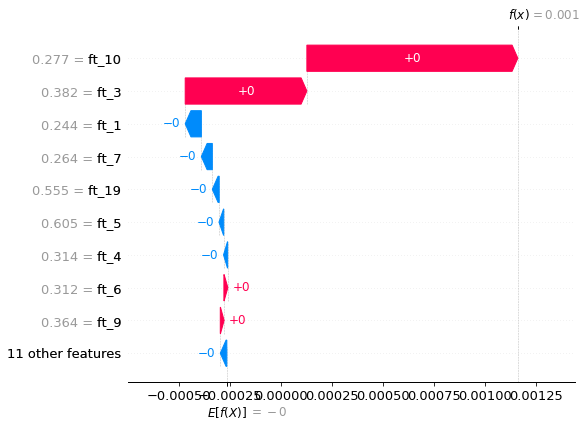

In [102]:
# J-SVD explainer to only one instance (local explanation)

target_pos= 2

target_inst_ox= train_ox.iloc[target_pos].to_frame().T
target_labl_ox= labels_train_ox.iloc[target_pos].to_frame().T

jsvd_phis, jsvd_ft_rk, jsvd_sh_exp= jsvd_explainer(xgb_model_ox, train_ox, labels_train_ox, 
                                                   target_inst_ox, target_labl_ox,
                                                   h_min=0.05, h_max=0.5, eps=10e-5, max_itr=10, 
                                                   finite_diff_version=2, verbose=True)

shap.plots.waterfall(jsvd_sh_exp)

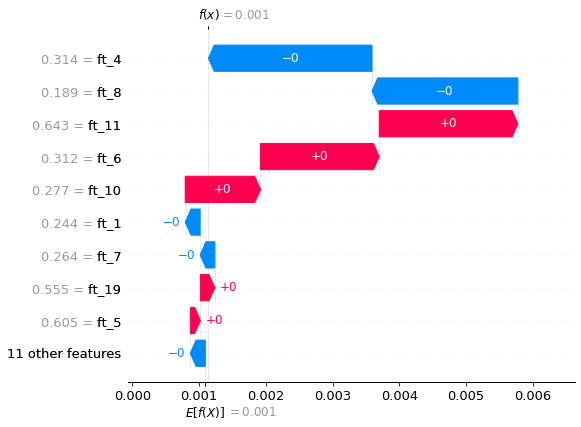

In [110]:
# SHAP explainer to only one instance (local explanation)

shap.plots.waterfall(shap_values_ox[target_pos])

In [ ]:
# J-SVD beeswarm plot -- finite_diff_version=2

jsvd_plots_sh_beeswarm(xgb_model, train, labels_train, h_min=0.05, h_max=0.5, eps=10e-3, max_itr=10, 
                       finite_diff_version=2, verbose=True)

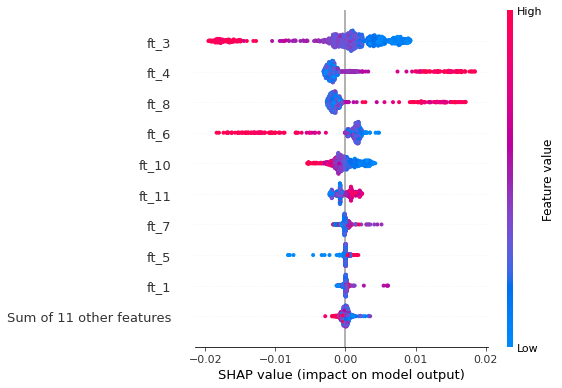

In [262]:
# Tests using SHAP

explainer_ox= shap.Explainer(xgb_model_ox)
shap_values_ox= explainer_ox(train_ox)
shap.plots.beeswarm(shap_values_ox, show=False)

# get the current figure and axes objects
fig, ax= plt.gcf(), plt.gca()

fig.axes[-1].set_aspect('auto')
plt.tight_layout()
fig.axes[-1].set_box_aspect(50)
plt.show()

In [88]:
# conversion of train_ox and labels_train_ox data back to tensor as required by benchmarking methods
# explanations will be only done over train dataset

tn_train= torch.from_numpy(train_ox.values)
tn_lb_tr= torch.from_numpy(labels_train_ox.values.ravel().astype(int))

In [94]:
# define a descriptor to OpenXAI synthetic

descriptor_ox= dict()

# J-SVD explanation settings
descriptor_ox['h_min']= 0.05
descriptor_ox['h_max']= 0.5
descriptor_ox['jacobian_eps']= 10e-3
descriptor_ox['max_itr']= 10
descriptor_ox['finite_diff_version']= 2

# perturbation settings used for the stability metric
descriptor_ox['num_perts']= 50
descriptor_ox['pert_max_distance']= 0.1
descriptor_ox['num_samples']= 100
descriptor_ox['num_runs']= 50
descriptor_ox['eps']= 0.001
descriptor_ox['feature_metadata']= ['c'] * n_ox
descriptor_ox['p_norm']= 2
descriptor_ox['top_k']= 0
descriptor_ox['mask']= generate_mask(tn_train[0].reshape(-1), descriptor['top_k'])

In [101]:
# Benchmarking methods over OpenXAI synthetic

In [ ]:
# evaluate relative input stability -- MAX
print('Max RIS -- (J-SVD, SHAP, LIME) --', 
      relative_stability(xgb_model_ox, train_ox, labels_train_ox, perturbation, descriptor, 
                         ris=True, max_mean=True))

In [ ]:
# evaluate relative input stability -- MEAN
print('Mean RIS -- (J-SVD, SHAP, LIME) --', 
      relative_stability(xgb_model_ox, train_ox, labels_train_ox, perturbation, descriptor, 
                         ris=True, max_mean=False))

In [ ]:
# evaluate relative output stability -- MAX
print('Max ROS -- (J-SVD, SHAP, LIME) --', 
      relative_stability(xgb_model_ox, train_ox, labels_train_ox, perturbation, descriptor, 
                         ris=False, max_mean=True))

In [ ]:
# evaluate relative output stability -- MEAN
print('Mean ROS -- (J-SVD, SHAP, LIME) --', 
      relative_stability(xgb_model_ox, train_ox, labels_train_ox, perturbation, descriptor, 
                         ris=False, max_mean=False))

In [ ]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (J-SVD, SHAP, LIME) --', run_stability(xgb_model_ox, train_ox, labels_train_ox, descriptor))

In [ ]:
# evaluate prediction gap on important features
print('PGI:', eval_pred_faithfulness(xgb_model_ox, train_ox, labels_train_ox, perturbation, descriptor))

In [ ]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (J-SVD, J-SVD ratio, SHAP, SHAP ratio) --', 
      eval_additive_exp_faithfulness(xgb_model_ox, train_ox, labels_train_ox, descriptor))